## Библиотеки

In [7]:
import os
import json
import csv
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms
from torchvision import datasets

In [8]:
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


## Seed

In [9]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Device

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## Воспамгательные функции (Метрики и графики)

In [11]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    

## Данные (KMNIST)

In [13]:
# Трансформации: ToTensor и Normalize
# FashionMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
#train_full = torchvision.datasets.KMNIST(
train_full = datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
#test_ds = torchvision.datasets.KMNIST(
test_ds = datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

100.0%


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


## train / validation split + DataLoader

In [14]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


## Модель MLP

In [15]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 10])


## Цикл обучения train/eval + no_grad + EarlyStoping (ранняя остановка)

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


## Fit

In [17]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

## Эксперимент E1 Base model

epoch 01/20 | train loss=1.1340, acc=0.6649 | val loss=0.7410, acc=0.7698
epoch 02/20 | train loss=0.6567, acc=0.7879 | val loss=0.6232, acc=0.8026
epoch 03/20 | train loss=0.5586, acc=0.8142 | val loss=0.5526, acc=0.8248
epoch 04/20 | train loss=0.5057, acc=0.8278 | val loss=0.5646, acc=0.8170
epoch 05/20 | train loss=0.4720, acc=0.8372 | val loss=0.5201, acc=0.8338
epoch 06/20 | train loss=0.4420, acc=0.8457 | val loss=0.5240, acc=0.8284
epoch 07/20 | train loss=0.4228, acc=0.8512 | val loss=0.5220, acc=0.8302
epoch 08/20 | train loss=0.4070, acc=0.8540 | val loss=0.5166, acc=0.8332
epoch 09/20 | train loss=0.3946, acc=0.8574 | val loss=0.4960, acc=0.8393
epoch 10/20 | train loss=0.3803, acc=0.8630 | val loss=0.5135, acc=0.8346
epoch 11/20 | train loss=0.3649, acc=0.8663 | val loss=0.5305, acc=0.8323
epoch 12/20 | train loss=0.3572, acc=0.8673 | val loss=0.5096, acc=0.8358
epoch 13/20 | train loss=0.3494, acc=0.8698 | val loss=0.5176, acc=0.8406
epoch 14/20 | train loss=0.3399, acc=0

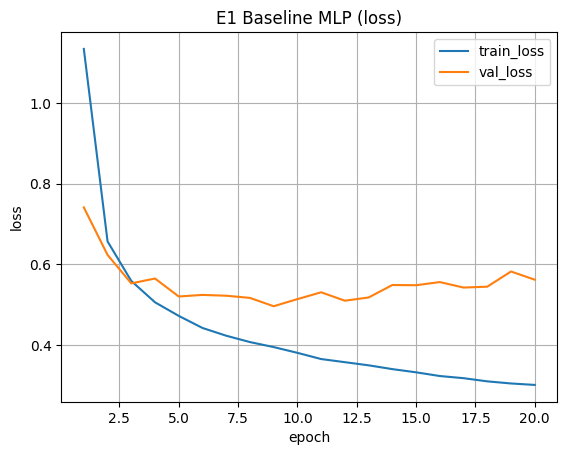

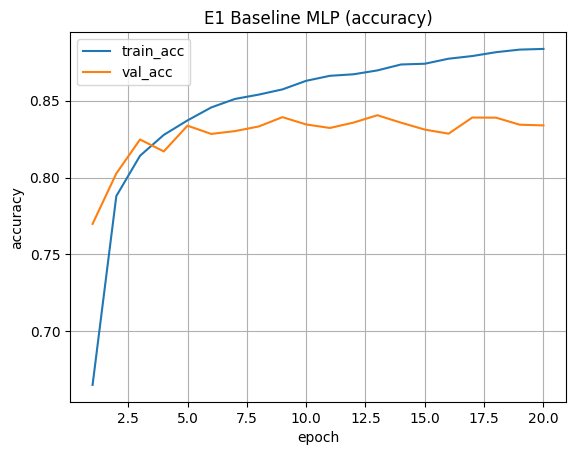

In [19]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
E1_model_baseline = MLP(hidden_dims=(256, 128), num_classes=47, dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E1_model_baseline.parameters(), lr=1e-3)

history_E1_model_baseline = fit(
    E1_model_baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_E1_model_baseline, title="E1 Baseline MLP")

## Эксперимент E2 Dropout

epoch 01/20 | train loss=1.5230, acc=0.5530 | val loss=0.8577, acc=0.7402
epoch 02/20 | train loss=1.0373, acc=0.6797 | val loss=0.7301, acc=0.7702
epoch 03/20 | train loss=0.9352, acc=0.7034 | val loss=0.6718, acc=0.7864
epoch 04/20 | train loss=0.8905, acc=0.7205 | val loss=0.6344, acc=0.7965
epoch 05/20 | train loss=0.8609, acc=0.7255 | val loss=0.6128, acc=0.8001
epoch 06/20 | train loss=0.8387, acc=0.7307 | val loss=0.6132, acc=0.7983
epoch 07/20 | train loss=0.8192, acc=0.7350 | val loss=0.5913, acc=0.8077
epoch 08/20 | train loss=0.8118, acc=0.7399 | val loss=0.5980, acc=0.8038
epoch 09/20 | train loss=0.7946, acc=0.7447 | val loss=0.5814, acc=0.8047
epoch 10/20 | train loss=0.7880, acc=0.7456 | val loss=0.5693, acc=0.8129
epoch 11/20 | train loss=0.7792, acc=0.7495 | val loss=0.5535, acc=0.8215
epoch 12/20 | train loss=0.7639, acc=0.7523 | val loss=0.5651, acc=0.8123
epoch 13/20 | train loss=0.7624, acc=0.7524 | val loss=0.5543, acc=0.8189
epoch 14/20 | train loss=0.7589, acc=0

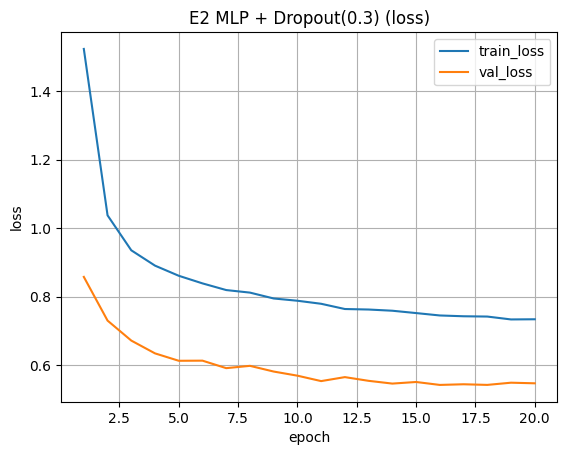

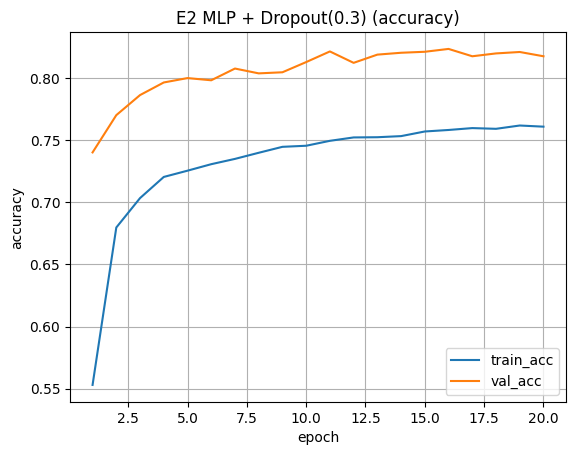

Dropout test: loss=0.5547, acc=0.8145


In [20]:
set_seed(42)
E2_dropout_model = MLP(hidden_dims=(256, 128), num_classes=47, dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E2_dropout_model.parameters(), lr=1e-3)

history_E2_dropout = fit(
    E2_dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_E2_dropout, title="E2 MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(E2_dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент E3 BatchNorm

epoch 01/20 | train loss=0.8872, acc=0.7437 | val loss=0.5649, acc=0.8183
epoch 02/20 | train loss=0.5281, acc=0.8228 | val loss=0.5131, acc=0.8300
epoch 03/20 | train loss=0.4596, acc=0.8424 | val loss=0.4696, acc=0.8430
epoch 04/20 | train loss=0.4174, acc=0.8529 | val loss=0.4653, acc=0.8447
epoch 05/20 | train loss=0.3858, acc=0.8617 | val loss=0.4568, acc=0.8443
epoch 06/20 | train loss=0.3655, acc=0.8693 | val loss=0.4471, acc=0.8498
epoch 07/20 | train loss=0.3445, acc=0.8731 | val loss=0.4503, acc=0.8497
epoch 08/20 | train loss=0.3268, acc=0.8781 | val loss=0.4567, acc=0.8488
epoch 09/20 | train loss=0.3133, acc=0.8824 | val loss=0.4426, acc=0.8541
epoch 10/20 | train loss=0.3011, acc=0.8865 | val loss=0.4472, acc=0.8513
epoch 11/20 | train loss=0.2895, acc=0.8897 | val loss=0.4494, acc=0.8532
epoch 12/20 | train loss=0.2775, acc=0.8931 | val loss=0.4578, acc=0.8537
epoch 13/20 | train loss=0.2678, acc=0.8964 | val loss=0.4678, acc=0.8511
epoch 14/20 | train loss=0.2625, acc=0

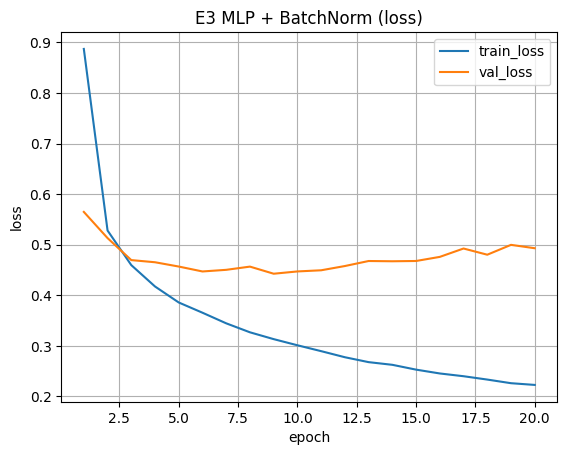

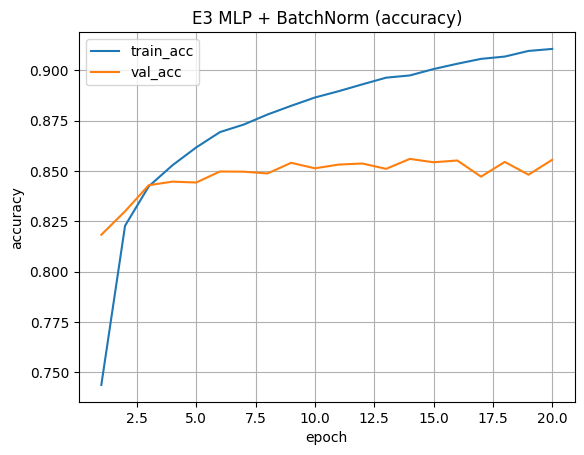

BatchNorm test: loss=0.5285, acc=0.8476


In [21]:
set_seed(42)
E3_bn_model = MLP(hidden_dims=(256, 128), num_classes=47, dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E3_bn_model.parameters(), lr=1e-3)

history_E3_bn = fit(
    E3_bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_E3_bn, title="E3 MLP + BatchNorm")
test_loss, test_acc = evaluate(E3_bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент E4 EarlyStopping

epoch 01/50 | train loss=1.2771, acc=0.6350 | val loss=0.6706, acc=0.7881
epoch 02/50 | train loss=0.8469, acc=0.7330 | val loss=0.5789, acc=0.8136
epoch 03/50 | train loss=0.7531, acc=0.7565 | val loss=0.5405, acc=0.8236
epoch 04/50 | train loss=0.7107, acc=0.7681 | val loss=0.5109, acc=0.8318
epoch 05/50 | train loss=0.6826, acc=0.7765 | val loss=0.4912, acc=0.8394
epoch 06/50 | train loss=0.6547, acc=0.7838 | val loss=0.4807, acc=0.8415
epoch 07/50 | train loss=0.6418, acc=0.7883 | val loss=0.4659, acc=0.8464
epoch 08/50 | train loss=0.6271, acc=0.7915 | val loss=0.4629, acc=0.8479
epoch 09/50 | train loss=0.6168, acc=0.7940 | val loss=0.4588, acc=0.8486
epoch 10/50 | train loss=0.6038, acc=0.7984 | val loss=0.4559, acc=0.8450
epoch 11/50 | train loss=0.5958, acc=0.7999 | val loss=0.4422, acc=0.8511
epoch 12/50 | train loss=0.5824, acc=0.8052 | val loss=0.4448, acc=0.8501
epoch 13/50 | train loss=0.5761, acc=0.8050 | val loss=0.4353, acc=0.8542
epoch 14/50 | train loss=0.5723, acc=0

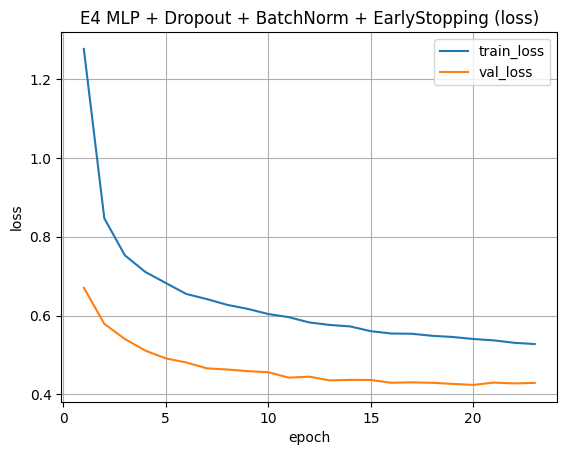

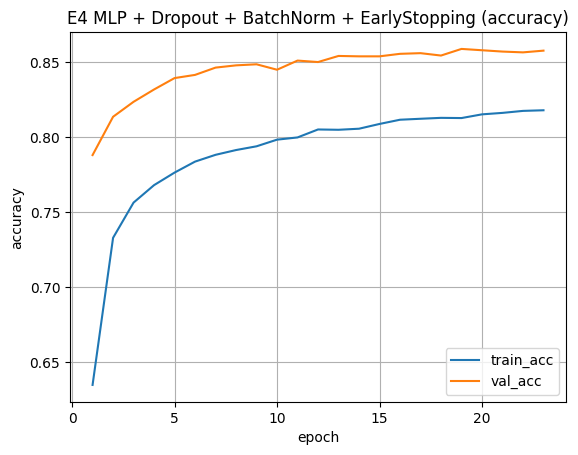

Combo test: loss=0.4406, acc=0.8495


In [22]:
set_seed(42)
E4_combo_model = MLP(hidden_dims=(256, 128), num_classes=47, dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E4_combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_E4_combo = fit(
    E4_combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_E4_combo, title="E4 MLP + Dropout + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(E4_combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## O1 (LR слишком большой)

epoch 01/6 | train loss=1.9342, acc=0.4374 | val loss=1.0822, acc=0.6661
epoch 02/6 | train loss=1.5991, acc=0.5219 | val loss=0.8932, acc=0.7127
epoch 03/6 | train loss=1.5230, acc=0.5413 | val loss=0.8777, acc=0.7279
epoch 04/6 | train loss=1.5104, acc=0.5431 | val loss=0.8611, acc=0.7193
epoch 05/6 | train loss=1.4951, acc=0.5453 | val loss=0.8020, acc=0.7396
epoch 06/6 | train loss=1.4628, acc=0.5572 | val loss=0.8413, acc=0.7227


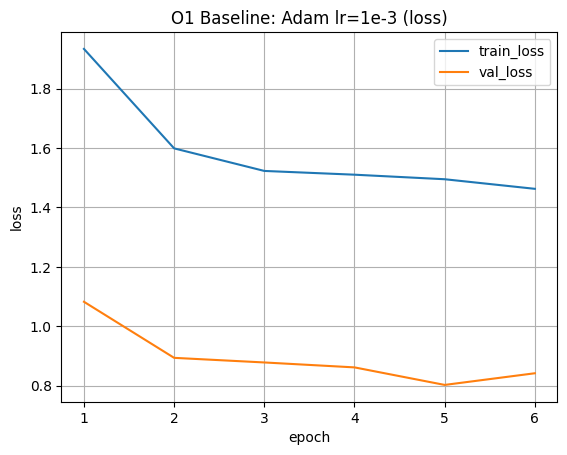

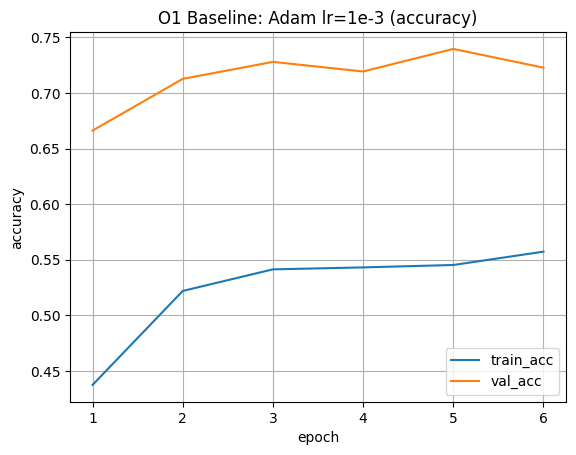

In [24]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

model_O1 = MLP(num_classes=47, dropout_p=0.3, use_batchnorm=True).to(device)
optimizer = optim.Adam(model_O1.parameters(), lr=1e-1)

O1_baseline_hist = fit(model_O1, train_loader, val_loader, 
                    optimizer, criterion, device, epochs=EPOCHS)
plot_history(O1_baseline_hist, title="O1 Baseline: Adam lr=1e-1")

## O2 (LR слишком маленький)

epoch 01/6 | train loss=3.5531, acc=0.1282 | val loss=3.1686, acc=0.3763
epoch 02/6 | train loss=3.0525, acc=0.3152 | val loss=2.7925, acc=0.4750
epoch 03/6 | train loss=2.7335, acc=0.4080 | val loss=2.4922, acc=0.5244
epoch 04/6 | train loss=2.4813, acc=0.4605 | val loss=2.2356, acc=0.5695
epoch 05/6 | train loss=2.2651, acc=0.5015 | val loss=2.0368, acc=0.5971
epoch 06/6 | train loss=2.0905, acc=0.5312 | val loss=1.8609, acc=0.6178


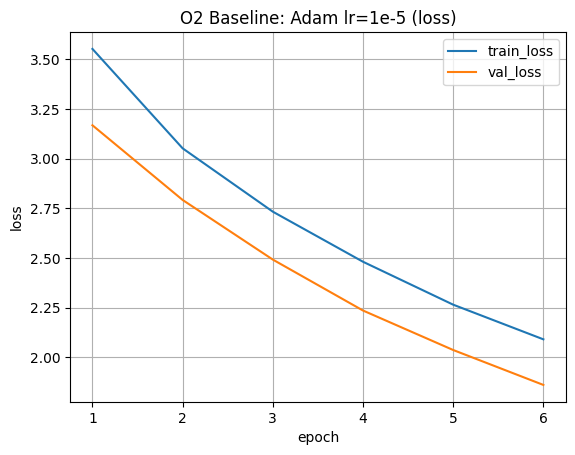

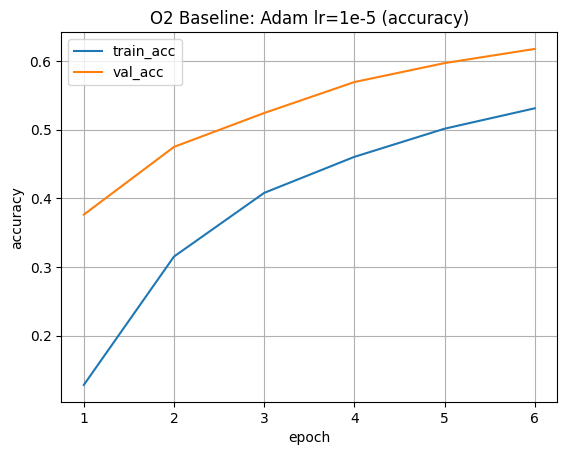

In [25]:
model_O2 = MLP(num_classes=47, dropout_p=0.3, use_batchnorm=True).to(device)
optimizer = optim.Adam(model_O2.parameters(), lr=1e-5)
history_O2 = fit(
    model_O2, train_loader, val_loader,
    optimizer, criterion, device, epochs=6)
plot_history(history_O2, title="O2 Baseline: Adam lr=1e-5")

## O3 (SGD + momentum + weight decay)

epoch 01/15 | train loss=1.3259, acc=0.6163 | val loss=0.7163, acc=0.7790
epoch 02/15 | train loss=0.9063, acc=0.7161 | val loss=0.6010, acc=0.8069
epoch 03/15 | train loss=0.8031, acc=0.7424 | val loss=0.5521, acc=0.8183
epoch 04/15 | train loss=0.7477, acc=0.7593 | val loss=0.5275, acc=0.8275
epoch 05/15 | train loss=0.7118, acc=0.7685 | val loss=0.5088, acc=0.8308
epoch 06/15 | train loss=0.6879, acc=0.7747 | val loss=0.4905, acc=0.8377
epoch 07/15 | train loss=0.6657, acc=0.7806 | val loss=0.4848, acc=0.8380
epoch 08/15 | train loss=0.6505, acc=0.7851 | val loss=0.4759, acc=0.8401
epoch 09/15 | train loss=0.6350, acc=0.7895 | val loss=0.4651, acc=0.8445
epoch 10/15 | train loss=0.6268, acc=0.7915 | val loss=0.4583, acc=0.8443
epoch 11/15 | train loss=0.6167, acc=0.7954 | val loss=0.4582, acc=0.8455
epoch 12/15 | train loss=0.6041, acc=0.7986 | val loss=0.4521, acc=0.8467
epoch 13/15 | train loss=0.6004, acc=0.7989 | val loss=0.4506, acc=0.8457
epoch 14/15 | train loss=0.5961, acc=0

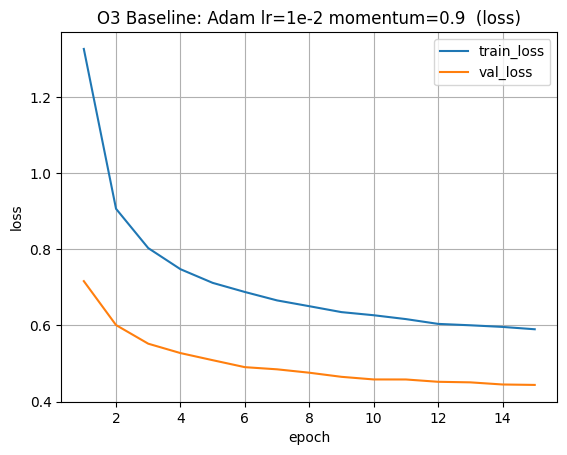

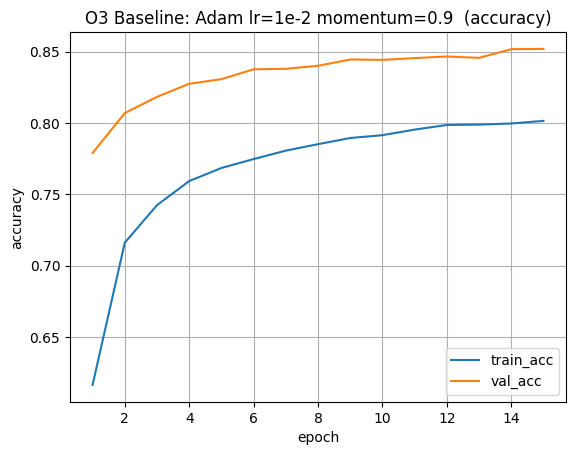

In [26]:
model_O3 = MLP(num_classes=47, dropout_p=0.3, use_batchnorm=True).to(device)
optimizer = optim.SGD(model_O3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
history_O3 = fit(
    model_O3, train_loader, val_loader,
    optimizer, criterion, device, epochs=15)
plot_history(history_O3, title="O3 Baseline: Adam lr=1e-2 momentum=0.9 ")

## Тест лучшей модели

In [27]:
test_loss, test_acc = evaluate(
    E4_combo_model,
    test_loader,
    criterion,
    device
)

print("BEST MODEL TEST")
print("loss:", test_loss)
print("acc:", test_acc)


BEST MODEL TEST
loss: 0.4405587679978942
acc: 0.8495429421768708


## Сохранение артефактов

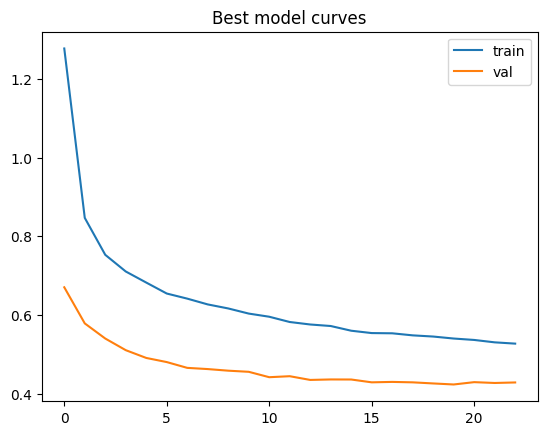

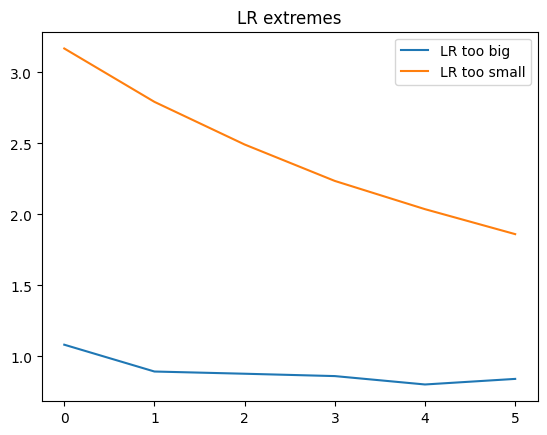

In [28]:
ART = Path("artifacts")
FIG = ART / "figures"
ART.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)


torch.save(E4_combo_model.state_dict(), ART / "best_model.pt")


config = {
    "dataset": "KMNIST",
    "hidden_dims": [256,128],
    "dropout": 0.3,
    "batchnorm": True,
    "optimizer": "Adam",
    "lr": 1e-3,
    "seed": 42
}
with open(ART / "best_config.json", "w") as f:
    json.dump(config, f, indent=2)


plt.figure()
plt.plot(history_E4_combo["train_loss"], label="train")
plt.plot(history_E4_combo["val_loss"], label="val")
plt.legend()
plt.title("Best model curves")
plt.savefig(FIG / "curves_best.png")


plt.figure()
plt.plot(O1_baseline_hist["val_loss"], label="LR too big")
plt.plot(history_O2["val_loss"], label="LR too small")
plt.legend()
plt.title("LR extremes")
plt.savefig(FIG / "curves_lr_extremes.png")





## runs.csv

In [29]:
rows = [
["E1","EMNIST",42,"256-128 relu", "Adam",1e-3,0,0,20,max(history_E1_model_baseline["val_acc"]),min(history_E1_model_baseline["val_loss"])],
["E2","EMNIST",42,"256-128 relu dropout", "Adam",1e-3,0,0,20,max(history_E2_dropout["val_acc"]),min(history_E2_dropout["val_loss"])],
["E3","EMNIST",42,"256-128 relu BN", "Adam",1e-3,0,0,20,max(history_E3_bn["val_acc"]),min(history_E3_bn["val_loss"])],
["E4","EMNIST",42,"256-128 relu dropout+BN", "Adam",1e-3,0,0,len(history_E4_combo["val_acc"]),max(history_E4_combo["val_acc"]),min(history_E4_combo["val_loss"])],
    
["O1","EMNIST",42,"256-128 relu dropout0.3 BN","Adam",1e-1,0,0,
len(O1_baseline_hist["val_acc"]),max(O1_baseline_hist["val_acc"]),min(O1_baseline_hist["val_loss"])],

["O2","EMNIST",42,"256-128 relu dropout0.3 BN","Adam",1e-5,0,0,
len(history_O2["val_acc"]),max(history_O2["val_acc"]),min(history_O2["val_loss"])],
    
["O3","EMNIST",42,"256-128 relu dropout0.3 BN","SGD",1e-2,0.9,1e-4,
len(history_O3["val_acc"]),max(history_O3["val_acc"]),min(history_O3["val_loss"])],    
]

with open(ART/"runs.csv","w",newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "experiment_id",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "momentum",
        "weight_decay",
        "epochs_trained",
        "best_val_accuracy",
        "best_val_loss"
    ])
    writer.writerows(rows)

